## Network Builder - Parts 1 and 2
### Skill-Based Occupational Network Construction
This notebook cleans ESCO occupation-skill data, builds the occupation-skill matrix, computes Jaccard similarity, and constructs the occupational network.

## 1. Import Libraries

We begin by importing the main libraries used for data manipulation, similarity computation, network construction, and visualization.

In [104]:
import pandas as pd
import numpy as np
import itertools
from collections import defaultdict

import networkx as nx
from sklearn.metrics import pairwise_distances

## 2. Load Data

We load the ESCO occupation-skill dataset, which contains the relationships between occupations and the skills associated with them.

In [105]:
df = pd.read_csv("occupationSkillRelations_en.csv")
df.head()

,occupationUri,occupationLabel,relationType,skillType,skillUri,skillLabel
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,knowledge,http://data.europa.eu/esco/skill/fed5b267-73fa...,theatre techniques
1,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/05bc7677-5a64...,organise rehearsals
2,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/271a36a0-bc7a...,write risk assessment on performing arts produ...
3,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/47ed1d37-971b...,coordinate with creative departments
4,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/591dd514-735b...,adapt to artists' creative demands


In [106]:
df.columns.tolist()

['occupationUri',
 'occupationLabel',
 'relationType',
 'skillType',
 'skillUri',
 'skillLabel']

In [107]:
df.shape

(126051, 6)

## 3. Missing Values Check

Before constructing the network, we check whether the relevant variables contain missing values.

In [108]:
(df.isnull().sum() / len(df)) * 100

occupationUri      0.000000
occupationLabel    0.000000
relationType       0.000000
skillType          0.046806
skillUri           0.000000
skillLabel         0.000000
dtype: float64

In [109]:
df[['occupationLabel', 'skillLabel']].isnull().sum()

occupationLabel    0
skillLabel         0
dtype: int64

## 4. Data Cleaning and Preparation

We clean the dataset by keeping only the relevant variables (occupation and skills) and removing duplicate entries. This ensures that each occupation-skill relationship is represented only once before constructing the network.

In [110]:
df_clean = df[['occupationLabel', 'skillLabel']].drop_duplicates()
df_clean.head()

,occupationLabel,skillLabel
0,technical director,theatre techniques
1,technical director,organise rehearsals
2,technical director,write risk assessment on performing arts produ...
3,technical director,coordinate with creative departments
4,technical director,adapt to artists' creative demands


In [111]:
df_clean.shape

(126051, 2)

## 5. Occupation-Skill Matrix Construction

We construct a binary matrix where rows represent occupations and columns represent skills. A value of 1 indicates that an occupation requires a given skill.

In [112]:
matrix = pd.crosstab(df_clean['occupationLabel'], df_clean['skillLabel'])
matrix.iloc[:5, :5]

skillLabel,3D body scanning technologies,3D lighting,3D modelling,3D printing process,3D texturing
occupationLabel,,,,,
3D animator,0,1,0,0,1
3D modeller,0,1,0,1,1
3D printing technician,0,0,1,1,0
ATM repair technician,0,0,0,0,0
EU funds manager,0,0,0,0,0


In [113]:
matrix.shape

(3039, 13475)

## 6. Jaccard Similarity Computation

We compute similarity between occupations using the Jaccard index. This measure captures the proportion of shared skills between two occupations relative to the total number of skills they possess.

Higher similarity implies that two occupations require similar skill sets and therefore represent more feasible transitions.

In [114]:
# Convert matrix to binary (True/False)
binary_matrix = matrix.astype(bool)

# Convert to numpy array
binary_array = binary_matrix.to_numpy()

# Compute Jaccard distance
jaccard_dist = pairwise_distances(binary_array, metric='jaccard')

# Convert distance to similarity
jaccard_sim = 1 - jaccard_dist

# Check result
print(jaccard_sim.shape)

(3039, 3039)


## 7. Threshold Sensitivity Analysis

To validate the network construction, we analyze how different similarity thresholds affect the structure of the occupational network. Lower thresholds produce denser networks, while higher thresholds retain only stronger and more meaningful connections.

This analysis helps justify the choice of the threshold used in the main network.

In [115]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for tau in thresholds:
    adj_tau = (jaccard_sim > tau).astype(int)
    np.fill_diagonal(adj_tau, 0)

    G_tau = nx.from_numpy_array(adj_tau)

    n_edges = G_tau.number_of_edges()
    density = nx.density(G_tau)
    n_components = nx.number_connected_components(G_tau)
    largest_cc = max(nx.connected_components(G_tau), key=len)
    largest_cc_size = len(largest_cc)

    results.append({
        "threshold": tau,
        "edges": n_edges,
        "density": density,
        "n_components": n_components,
        "largest_component_size": largest_cc_size
    })

results_df = pd.DataFrame(results)
results_df

,threshold,edges,density,n_components,largest_component_size
0,0.1,66870,0.014486,50,2977
1,0.2,28813,0.006242,445,1751
2,0.3,14103,0.003055,1025,416
3,0.4,8635,0.001871,1627,84
4,0.5,6412,0.001389,2044,44


### Threshold Sensitivity Plot

We visualize how the size of the largest connected component changes as the similarity threshold increases.

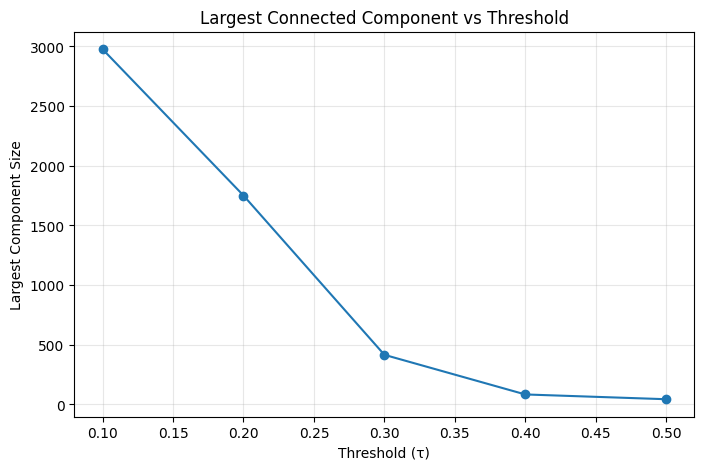

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["largest_component_size"], marker="o")
plt.title("Largest Connected Component vs Threshold")
plt.xlabel("Threshold (τ)")
plt.ylabel("Largest Component Size")
plt.grid(True, alpha=0.3)
plt.show()


The threshold sensitivity analysis shows that lower thresholds produce highly connected networks, while higher thresholds lead to increasingly fragmented structures.

At higher thresholds, the network becomes overly sparse, with the largest connected component including only a small fraction of occupations. This indicates that the similarity criterion is too restrictive, eliminating many plausible connections between occupations and limiting the ability to capture meaningful transition pathways. As the threshold is reduced, connectivity increases but we risk overestimating similarity across occupations. 

**At τ = 0.2**, the network retains a large connected core while also revealing several substantial secondary components. This indicates a more structured occupational space, where transitions are possible within and across major clusters but still constrained by meaningful differences in skill requirements. Therefore, τ = 0.2 is preferred as it balances connectivity with structural differentiation, providing a more realistic representation of occupational mobility.

## 8. Network Construction

We construct a network where nodes represent occupations and edges connect occupations with similarity above a given threshold τ. This allows us to focus on meaningful transitions between occupations.

In [127]:
# Set threshold
threshold = 0.2
occ_labels = matrix.index.tolist()

# Build weighted graph with occupation labels as node names
G = nx.Graph()
G.add_nodes_from(occ_labels)

rows, cols = np.where(jaccard_sim > threshold)
for r, c in zip(rows, cols):
    if r < c:  # avoid duplicates and self-loops
        G.add_edge(occ_labels[r], occ_labels[c], weight=jaccard_sim[r, c])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 3039
Number of edges: 28813


## Summary

In this section, we cleaned the ESCO data, constructed the occupation-skill matrix, computed occupational similarity using the Jaccard index, built the occupational network, and justified the selection of the threshold used in the main analysis.

In [118]:
# Export threshold sensitivity results
#results_df.to_csv("threshold_sensitivity_results.csv", index=False)

# Export Jaccard similarity matrix
#pd.DataFrame(jaccard_sim, index=matrix.index, columns=matrix.index).to_csv("jaccard_similarity_matrix.csv")

# Export network edges with weights
#nx.write_graphml(G, "occupational_network_tau03.graphml")

## 10. Network Overview


We compute basic descriptive statistics of the occupational network. Specifically, we measure the number of nodes (occupations), the number of edges (similarity-based connections), network density (the proportion of possible connections that are realized), and the average degree (average number of connections per occupation).

In [128]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)

degrees = dict(G.degree())
avg_degree = sum(degrees.values()) / n_nodes

print("=== Network Overview ===")
print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Density: {density:.4f}")
print(f"Average degree: {avg_degree:.2f}")

=== Network Overview ===
Number of nodes: 3039
Number of edges: 28813
Density: 0.0062
Average degree: 18.96


The occupational network consists of 3,039 nodes and 28,813 edges, with a density of 0.0062. While the network remains relatively sparse compared to a fully connected graph, this density indicates a moderate level of interconnectedness across occupations. A non-negligible share of occupation pairs exhibit meaningful skill similarity, allowing for multiple potential transition pathways.

The average degree is 18.96, meaning that, on average, each occupation is connected to approximately 19 others. This suggests that many occupations have a substantial but not excessive set of similar alternatives, reflecting meaningful overlap in skill requirements while still preserving differentiation across roles.

## 11. Connectivity Analysis


We analyze the structure of the network by identifying connected components, groups of occupations, that are reachable from one another through paths of similarity links. We also compute the size of the largest connected component and its share of total nodes.

In [129]:
n_components = nx.number_connected_components(G)
components = list(nx.connected_components(G))

largest_cc = max(components, key=len)
largest_cc_size = len(largest_cc)
largest_cc_share = largest_cc_size / n_nodes

print("\n=== Connectivity Analysis ===")
print(f"Number of connected components: {n_components}")
print(f"Largest component size: {largest_cc_size}")
print(f"Share of nodes in largest component: {largest_cc_share:.4f}")


=== Connectivity Analysis ===
Number of connected components: 445
Largest component size: 1751
Share of nodes in largest component: 0.5762


The network contains 445 connected components, indicating a moderate level of fragmentation. The largest connected component includes 1,751 occupations, representing approximately 57.62% of the network.

This suggests that the occupational space is partially integrated, with a large core of interconnected occupations but also a significant number of smaller, separate components. Unlike highly connected networks, where nearly all occupations are reachable, or highly fragmented ones, where transitions are severely limited, this structure reflects a balance between connectivity and segmentation.

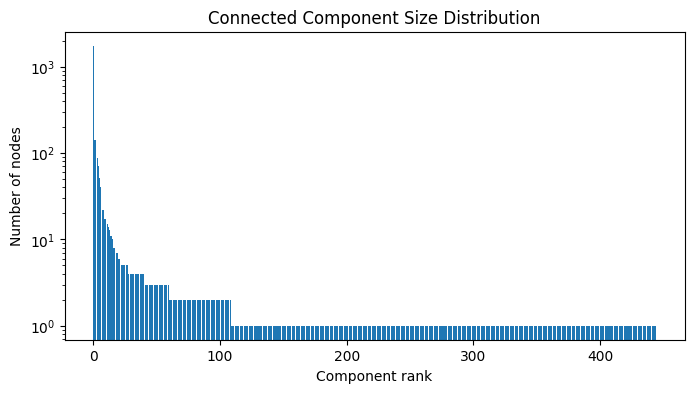

Number of isolated nodes: 336
Component sizes (top 10): [1751, 142, 141, 87, 71, 51, 40, 22, 22, 17]


In [130]:
component_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)

plt.figure(figsize=(8, 4))
plt.bar(range(len(component_sizes)), component_sizes)
plt.title("Connected Component Size Distribution")
plt.xlabel("Component rank")
plt.ylabel("Number of nodes")
plt.yscale("log")
plt.show()

print(f"Number of isolated nodes: {sum(1 for s in component_sizes if s == 1)}")
print(f"Component sizes (top 10): {component_sizes[:10]}")

The distribution reveals a big component containing 1,751 nodes, which towers above all other components on the log scale. The second and third largest components contain only 142 and 141 nodes, and the drop-off is steep. Beyond rank ~110, all remaining components are size 1, giving 336 isolated nodes. The network exhibits a clear core-periphery structure, meaning a single dominant cluster has formed, while a substantial fraction of nodes remain in small disconnected subgroups or are entirely isolated.

The presence of several sizable secondary components (e.g., components with over 100 occupations) indicates that the labor market is organized into distinct submarkets or clusters, within which transitions are more feasible. Occupations outside the largest component may represent more specialized roles with limited connectivity to the broader occupational space.

## 12. Degree Distribution 

We examine how connections are distributed across occupations by plotting the degree distribution. This shows how many occupations have few versus many connections.

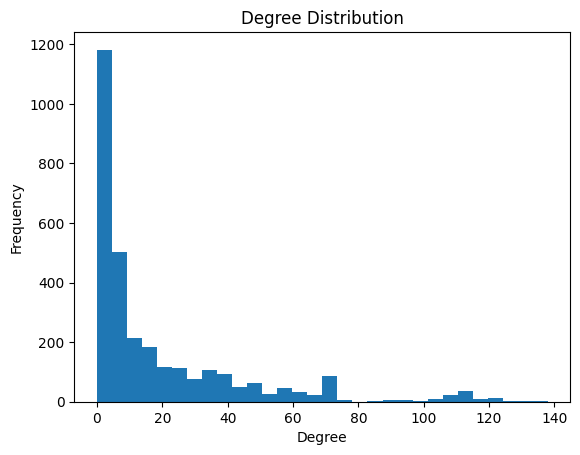

In [131]:
degree_values = list(degrees.values())

plt.figure()
plt.hist(degree_values, bins=30)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

The degree distribution is strongly right-skewed, indicating that most occupations have relatively few connections, while a small number of occupations have a large number of links.

This suggests the presence of hub occupations with broadly transferable skills, which are connected to many other roles and may facilitate transitions across different parts of the network. In contrast, the majority of occupations remain more specialized, with fewer direct connections.

Within this moderately connected network, the uneven distribution of links highlights heterogeneity in transition opportunities, where some occupations occupy central positions with high flexibility, while others remain more constrained within specific segments of the labor market.

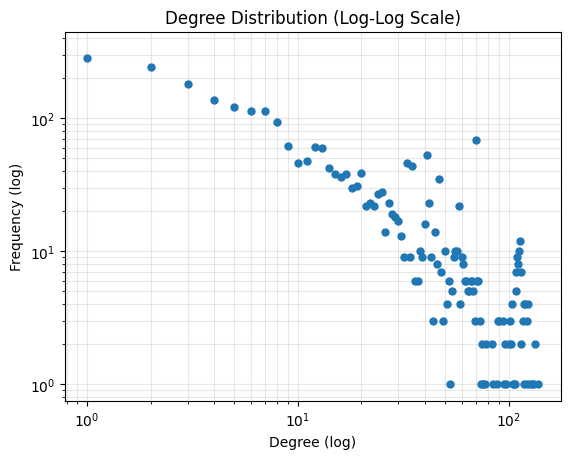

In [132]:
degree_values = list(dict(G.degree()).values())
counts = np.bincount(degree_values)
degrees_x = np.nonzero(counts)[0]
counts_y = counts[degrees_x]

plt.figure()
plt.loglog(degrees_x, counts_y, 'o', markersize=5)
plt.title("Degree Distribution (Log-Log Scale)")
plt.xlabel("Degree (log)")
plt.ylabel("Frequency (log)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

The log-log plot displays a clear negative linear trend, consistent with a heavy-tailed, approximately power-law distribution. Low-degree nodes are abundant, while high-degree nodes exist but are rare, with the maximum degree reaching just above 10². The scatter increases at higher degrees, which is typical for empirical networks of this size. This heterogeneous structure indicates the network is not random, connectivity is highly unequal across nodes, with a small number of hubs and a large majority of lightly connected nodes.

## 13. Network Visualization

To make the network interpretable, we visualize a sample of 100 nodes from the largest connected component. Node size reflects degree (number of connections), and only the most connected nodes are labeled to reduce visual clutter.

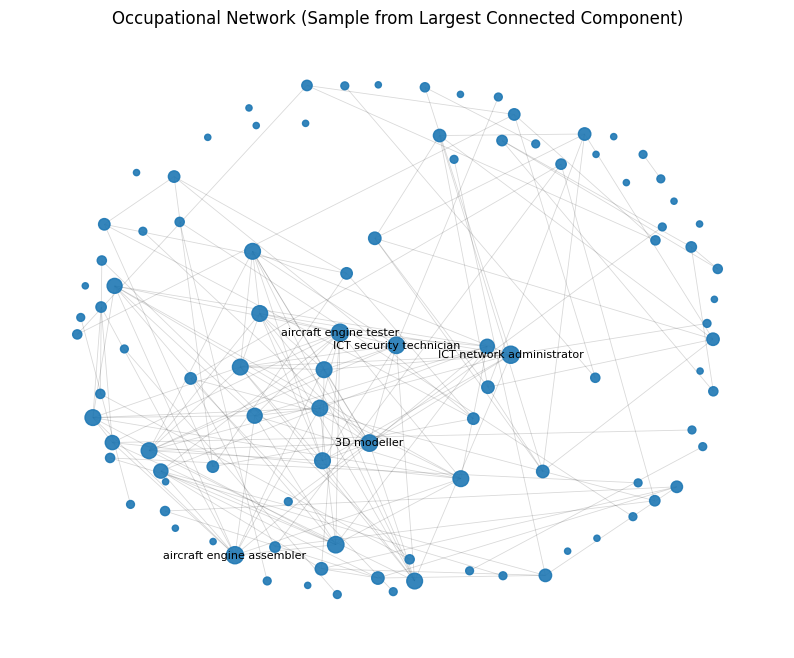

In [133]:
import networkx as nx

# Extract largest connected component
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc_nodes).copy()

# Take a sample of 100 nodes 
sample_nodes = list(G_lcc.nodes())[:100]
G_vis = G_lcc.subgraph(sample_nodes).copy()

#  Node sizes based on degree
degrees = dict(G_vis.degree())
node_sizes = [degrees[n] * 12 + 20 for n in G_vis.nodes()]

# 4. Label top 5 nodes
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:5]
labels = {n: n for n in top_nodes}

# 5. Layout
pos = nx.spring_layout(G_vis, seed=42, k=0.9)

# 6. Plot
plt.figure(figsize=(10, 8))

nx.draw_networkx_edges(G_vis, pos, alpha=0.15, width=0.6)
nx.draw_networkx_nodes(G_vis, pos, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8)

plt.title("Occupational Network (Sample from Largest Connected Component)")
plt.axis("off")
plt.show()

The visualization reveals a structured and partially interconnected network, consistent with the presence of a large but not dominant connected component. While many occupations are linked through direct or indirect connections, the network does not collapse into a single fully integrated structure.

Within this structure, areas of higher density can be observed, indicating groups of occupations that share similar skill requirements and form cohesive clusters. Larger nodes, representing occupations with higher degree, tend to occupy more central positions and may act as connectors within and across these clusters, facilitating transitions within the broader occupational space.

At the same time, the presence of peripheral and weakly connected nodes reflects occupations with more specialized skill sets, which may face greater barriers to mobility. Overall, the visualization highlights a labor market that is connected but segmented, where mobility is feasible within clusters but not uniformly across all occupations.

## 14. Summary statistics

In [125]:
stats = {
    "Nodes": G.number_of_nodes(),
    "Edges": G.number_of_edges(),
    "Density": round(nx.density(G), 6),
    "Avg Degree": round(sum(dict(G.degree()).values()) / G.number_of_nodes(), 2),
    "Connected Components": nx.number_connected_components(G),
    "Largest Component (nodes)": len(max(nx.connected_components(G), key=len)),
    "Largest Component (% of total)": round(
        len(max(nx.connected_components(G), key=len)) / G.number_of_nodes() * 100, 2
    ),
    "Max Degree": max(dict(G.degree()).values()),
    "Min Degree": min(dict(G.degree()).values()),
}

pd.DataFrame(stats.items(), columns=["Metric", "Value"])

,Metric,Value
0,Nodes,3039.000000
1,Edges,28813.000000
2,Density,0.006242
3,Avg Degree,18.960000
4,Connected Components,445.000000
5,Largest Component (nodes),1751.000000
6,Largest Component (% of total),57.620000
7,Max Degree,138.000000
8,Min Degree,0.000000


The summary statistics indicate a network that is sparse but meaningfully connected. With 3,039 nodes, 28,813 edges, and a density of 0.0062, only a small share of possible connections are realized, reflecting selective but relevant skill similarities between occupations.

The average degree of 18.96 suggests that occupations have a moderate number of feasible alternatives, while the high maximum degree (138) indicates the presence of hub occupations with broadly transferable skills. In contrast, the existence of isolated nodes (degree 0) highlights highly specialized roles with limited mobility.

Structurally, the network is partially integrated, with 57.62% of occupations in the largest connected component and the remainder distributed across smaller components. This suggests a labor market composed of a large core alongside distinct submarkets, where mobility is possible but uneven across occupations.